# NF $h_{\rm dm}$ fit — free total flow time $\Delta t$ (single centred Gaussian $f_0$)

The Hamiltonian flow integrates over a total dynamical time
$$\Delta t \;=\; N_{\rm steps} \times dt ,$$
and this notebook fits **both** $h_{\rm dm}$ and $\Delta t$, jointly with the
normalizing-flow bijection — six parameters in all.

### What is fitted

Leapfrog accuracy and stability constrain the **timestep**, not the step count,
so $dt$ is **pinned in advance** at `C.DT_STEP` $= 0.5$ Myr and the free
parameter is the **step count** $N_{\rm steps} = \Delta t / dt$ — and therefore
the total time.  At the truth $N_{\rm steps} = 800$.  $N_{\rm steps}$ is
real-valued: the integrator takes $\lfloor N\rfloor$ full KDK steps plus one
closing *partial* step, so the likelihood stays a smooth, differentiable
function of the total time while every step actually taken is the same safely
small $dt$ — 163 steps per 81.5 Myr vertical oscillation, $1/52$ of the leapfrog
stability limit $2/\nu = 26$ Myr.

The other four parameters are the bijection's, $x = a\,u + b$ on each axis.  For
that flow the maximum-likelihood $a$ and $b$ at any fixed $(h_{\rm dm}, \Delta t)$
are the standard deviation and mean of the back-integrated cloud, so they are
solved **exactly, in closed form** rather than by gradient descent, and the
search runs over the 2-D *profile* likelihood.  (Verified against an explicit
numerical minimisation over all four: agreement to $3\times10^{-11}$ nats, on
clouds with kurtosis $\approx 1$ — no Gaussianity of the *data* is assumed.)

### The two figures

1. **the simulated data** — the snapshot being fitted;
2. **the convergence figure** — the $(h_{\rm dm}, \Delta t)$ likelihood
   landscape, with the routes basin hopping takes across it from widely
   separated initial guesses, and every one of the 32 final fits in the inset.

Sections after that cover how the fitter was tuned, how to run the study on a
cluster, what one fit costs, and a table of every fitted parameter.

> **Note on an earlier version.**  This notebook used to show two landscape
> figures built on `C.joint_fit_h_dt`, whose first stage (`C.dealias_scan`)
> **discards the initial guess**: its $h_{\rm dm}$ ladder and $\Delta t$ grid are
> fixed, so every start returned the identical pair $(320, 396)$ and every fit
> the identical $h$ to the last bit.  Their "spread across starts $= 0.00$" was
> not a robustness measurement but the same number printed $N$ times.  Those
> figures have been removed and replaced by the basin-hopping study, which
> genuinely starts at the initial guess.


In [ ]:
%matplotlib inline
# reload the experiments package so a kernel started before an edit picks up the
# latest code (restart the kernel if a stale-module AttributeError persists).
import importlib, experiments.common, experiments
importlib.reload(experiments.common); importlib.reload(experiments)
import numpy as np
import experiments as X
from experiments import common as C

# ---- knobs -------------------------------------------------------------------
N = 20_000                 # stars the fit uses
N_DISPLAY = 4 * N          # stars for the sim-data HEATMAP only -- NOT the fit

z_obs, w_obs = C.make_gaussian_data(N=N, seed_sample=3)
z_disp, w_disp = C.make_gaussian_data(N=N_DISPLAY, seed_sample=3)
true_pdf_z = lambda g: C.gauss_pdf(g, 0.0, C.Z0_SIGMA)
true_pdf_w = lambda g: C.gauss_pdf(g, 0.0, C.W0_SIGMA)

# ---- 2D heatmap display window for figure 1 (edit Q_CLIP to zoom) -----------
Q_CLIP = 97.0
zc = np.percentile(np.abs(z_obs - np.median(z_obs)), Q_CLIP)
wc = np.percentile(np.abs(w_obs - np.median(w_obs)), Q_CLIP)
ZLIM = (-zc, zc)
WLIM = (np.median(w_obs) - wc, np.median(w_obs) + wc)

# The TIMESTEP is fixed in advance; the free parameter is the STEP COUNT.
print(f"N(fit)={N}  N(display)={N_DISPLAY}")
print(f"leapfrog timestep  dt = {C.DT_STEP} Myr  (fixed, ceiling {C.DT_STEP_MAX} Myr; "
      f"vertical period 2*pi/nu = {2*np.pi/C.NU:.1f} Myr -> {2*np.pi/C.NU/C.DT_STEP:.0f} steps/period, "
      f"1/{(2/C.NU)/C.DT_STEP:.0f} of the stability limit 2/nu = {2/C.NU:.1f} Myr)")
print(f"free parameter     N_steps = dt_total / {C.DT_STEP};  truth: h_dm = {C.H_TRUE:.0f} pc, "
      f"dt_total = {C.DT_TRUE:.0f} Myr  (N_steps = {C.N_STEPS_TRUE:.0f})")


## The simulation: every parameter of the data

Everything the snapshot depends on, in one place.  Nothing below is fitted except
$h_{\rm dm}$ and $\Delta t$; the potential's other components and the true $f_0$
are fixed and known, which is what makes this an injection–recovery test.

**The true initial distribution function** is a single centred, separable
Gaussian in the midplane phase-space coordinates,
$$f_0(z, w) \;=\; \mathcal{N}(z;\, \mu_z,\, \sigma_{z_0})\;
                  \mathcal{N}(w;\, \mu_w,\, \sigma_{w_0}),
\qquad \mu_z = \mu_w = 0 ,$$
with $\sigma_{w_0} = 20$ km/s chosen and
$\sigma_{z_0} = \sigma_{w_0}/\nu$ set to the **equilibrium** value for that
dispersion ($\nu$ = midplane vertical frequency).  So the cloud starts as a
stationary, phase-mixed blob; the spiral in figure 1 is produced purely by
evolving it for $\Delta t = 400$ Myr in the anharmonic potential.

**The potential** is a sum of three baryonic $\mathrm{sech}^2$ sheets plus one
dark-matter $\mathrm{sech}^2$ sheet,
$$\Phi(z) \;=\; \sum_i 4\pi G \rho_i h_i^2 \ln\cosh(z/h_i),$$
each the 1-D Poisson solution for $\rho(z) = \rho_i\,\mathrm{sech}^2(z/h_i)$.
The dark-matter sheet contributes only $\approx 9\%$ of the midplane density —
which is the root cause of the $h_{\rm dm}$/$\Delta t$ asymmetry analysed in
figure 2 and in `hdm_dt_stiffness.pdf`.

The cell below prints the live values straight from the simulation object, so it
cannot go stale.


In [ ]:
import math
import pandas as pd

s = C.sim

# ---- the potential ----------------------------------------------------------
comp = pd.DataFrame(
    [("thin disc",  s.rho0_thin,  s.h_thin_pc,  "fixed"),
     ("thick disc", s.rho0_thick, s.h_thick_pc, "fixed"),
     ("gas",        s.rho0_gas,   s.h_gas_pc,   "fixed"),
     ("dark matter", s.rho_DM,    s.h_pc_dm,    "h FITTED")],
    columns=["component", "rho_0 [Msun/pc^3]", "h [pc]", "status"])
rho_b = s.rho0_thin + s.rho0_thick + s.rho0_gas
rho_t = rho_b + s.rho_DM

print("POTENTIAL   Phi(z) = sum_i 4 pi G rho_i h_i^2 ln cosh(z/h_i)")
print(comp.to_string(index=False))
print(f"  baryon midplane density  rho_b(0) = {rho_b:.4f} Msun/pc^3")
print(f"  total  midplane density  rho_t(0) = {rho_t:.4f} Msun/pc^3")
print(f"  DM share of rho_t(0)              = {s.rho_DM/rho_t*100:.2f} %   <-- why h_dm is weakly constrained")
print(f"  G = {s.G} pc (km/s)^2 / Msun      MYR_TO_TUNIT = {s.MYR_TO_TUNIT}")
print(f"  z grid half-width z_max           = {s.z_max_pc} pc")

# ---- derived scales ---------------------------------------------------------
print()
print("DERIVED")
print(f"  midplane frequency  nu = sqrt(4 pi G rho_t(0)) = {C.NU:.6f} /Myr")
print(f"  vertical period     2 pi / nu                  = {2*math.pi/C.NU:.2f} Myr")
print(f"  leapfrog stability limit 2/nu                  = {2/C.NU:.2f} Myr")
print(f"  timestep used       dt = {C.DT_STEP} Myr = 1/{(2/C.NU)/C.DT_STEP:.0f} of that limit, "
      f"{2*math.pi/C.NU/C.DT_STEP:.0f} steps/period")

# ---- the true f0 ------------------------------------------------------------
print()
print("TRUE f0  (single centred separable Gaussian, NOT fitted -- the target)")
print(f"  mean      mu_z = 0.0 pc          mu_w = 0.0 km/s")
print(f"  sigma     sigma_z0 = {C.Z0_SIGMA:.3f} pc   sigma_w0 = {C.W0_SIGMA:.3f} km/s")
print(f"  sigma_z0 is the EQUILIBRIUM value sigma_w0 / nu for this sigma_w0")
print(f"  typical z/h = sigma_z0 / h_true = {C.Z0_SIGMA/C.H_TRUE:.2f}   (order unity: NO small-z/h expansion is valid)")

# ---- truth + how the snapshot was made --------------------------------------
print()
print("TRUTH BEING RECOVERED")
print(f"  h_dm     = {C.H_TRUE:.1f} pc")
print(f"  Delta t  = {C.DT_TRUE:.1f} Myr   (= N_steps * dt, N_steps = {C.N_STEPS_TRUE:.0f})")
print()
print("SNAPSHOT GENERATION  (C.make_gaussian_data)")
print(f"  sample f0        : sim.sample_near_midplane(N, mu, sigma, seed=seed_sample=3)")
print(f"  evolve forward   : sim.evolve_record(..., t_obs_myr={C.T_OBS:.0f}, n_steps=12000,")
print(f"                     n_snaps=10, seed=seed_evolve=0, use_satellite=False, h_pc_dm={C.H_TRUE:.0f})")
print(f"  satellite        : OFF  (Sigma_sat={s.Sigma_sat}, sigma_t={s.sigma_t_myr} Myr -- unused here)")
print(f"  N (fit)          : {N}          N (display heatmap only): {N_DISPLAY}")
print()
print("FITTED IN THIS NOTEBOOK: h_dm, Delta t, and the 4 bijection parameters (a_z, a_w, b_z, b_w).")
print("Everything else above is held at its true value.")


## Figure 1 — the simulated data

The snapshot being fitted, as phase-space heatmaps: **rows** = the two times
($t=0$ back-integrated, $t=400$ Myr observed), **columns** = the density $f(z,w)$
and its residual (density minus its azimuthal average, exposing the phase-space
**spiral**).  The overall *winding angle* of that spiral is set by the total
dynamical time $\Delta t$ — which is exactly the parameter fitted below.


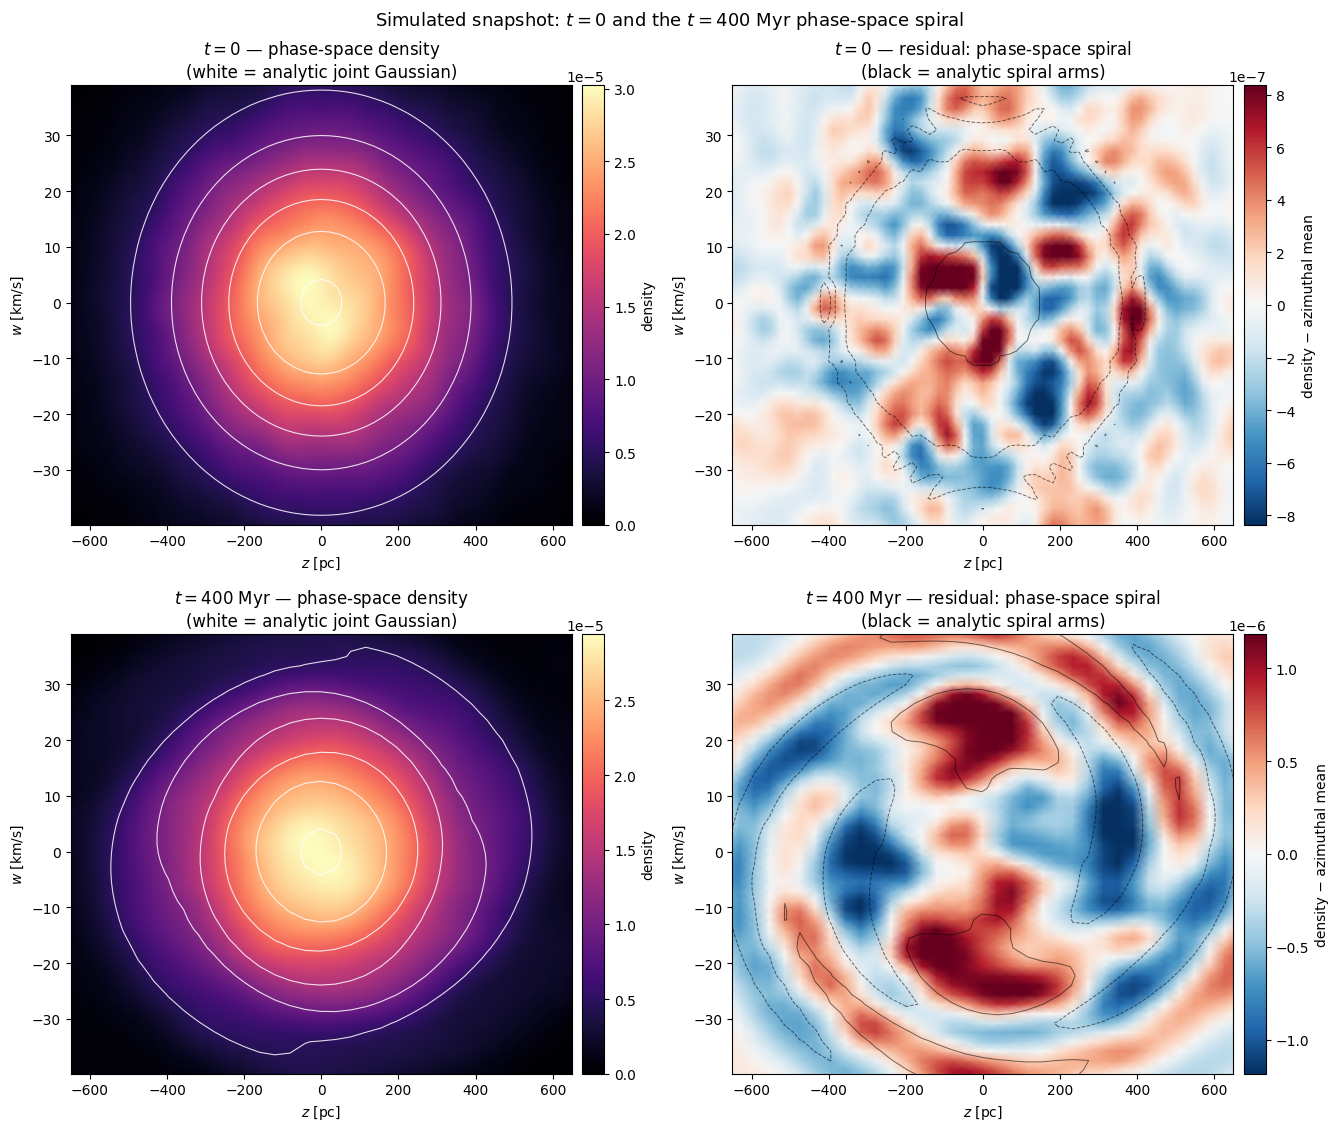

In [ ]:
C.plot_simulated_data(z_disp, w_disp, true_pdf_z, true_pdf_w,
                     zlim=ZLIM, wlim=WLIM,
                     title="Simulated snapshot: $t=0$ and the $t=400$ Myr phase-space spiral");

---
## Figure 2 — every initial guess reaches the same minimum

`C.basin_hop_h_dt` is a global optimiser that **starts at the initial guess** and
searches outward, so unlike the sweep it can actually be tested for
initialisation dependence.  From your starting point:

1. **locally minimise where you started — over ALL parameters together**:
   $h_{\rm dm}$, $\Delta t$ and every parameter of the bijection in one
   L-BFGS minimisation of the likelihood (full batch on the 4000-star subsample;
   $h$ enters in units of 10 pc so all coordinates have comparable curvature);
2. **jump** from the *current* point — $\Delta t$ by
   $\mathcal{N}(0, 55\ \mathrm{Myr})$, or $\pm220$ Myr one time in four;
   $h_{\rm dm}$ by $\mathcal{N}(0, 45\ \mathrm{pc})$;
3. **locally minimise again, jointly**, starting the bijection from the
   parameters *of the stored best point*.  Keep the new point (with its
   bijection) only if its likelihood is better; otherwise it is discarded and the
   next jump starts from the stored point again;
4. repeat until 25 consecutive hops fail to improve;
5. **refine the winner on the full 20 000-star sample** — the same joint
   minimisation of all parameters.

The local step stops only when the likelihood **and** the position in
$(h_{\rm dm}, \Delta t)$ have both stopped changing for three iterations: along
the $h$–$\Delta t$ degeneracy ridge the likelihood can change by $<10^{-4}$ nats
per iteration while $h$ is still sliding (a likelihood-only rule stopped 120 pc
short of the minimum).  Checked against the earlier profile fit (Nelder-Mead over
$(h,\Delta t)$ with the bijection solved separately at every point): the joint
minimisation lands on the same point to 0.01 pc / 0.001 Myr.

The jump is what crosses the comb's 100–300-nat barriers, and it crosses them for
free: it re-descends where it lands instead of climbing over the ridge.  Step 5
is not cosmetic — the 4000-star subsample used while hopping identifies the right
*tooth* but its own minimum sits $\sim\!65$ pc away in $h_{\rm dm}$, worth 3.5
nats, because $h_{\rm dm}$ is the soft direction.

**Reading the figure.**  **Squares** are initial guesses, **circles** are where
that run finished, and the line between them is the route.  Only three routes
are drawn — all 32 at once is an unreadable tangle, and the left panel's job is
to show *how* a walker gets there.  The **right panel** carries the count: the
$(h_{\rm dm}, \Delta t)$ plane with every final fit drawn with its $1\sigma$
profile-likelihood error bars, and the truth as a gold star.  The fits agree to
$\sim$0.04 pc and 0.002 Myr — far inside their error bars — so on that scale
they sit on top of each other; the **inset** magnifies the landing points so the
individual fits can be seen.

Two things worth reading off it:

* **The routes are violent in $h_{\rm dm}$ and disciplined in $\Delta t$** — a
  typical one runs $(600,60) \to (800,81) \to (800,226) \to (220,294) \to
  (50,465) \to (766,436) \to (187,403) \to (252.4, 399.78)$, slamming between
  the $h$ clamps while $\Delta t$ marches monotonically onto the true tooth.
  That is the 32$\times$ stiffness rendered as a search trajectory: greedy
  acceptance lets $h_{\rm dm}$ roam almost freely because it costs so little
  likelihood.
* **The 32 final fits lie along a diagonal streak** in the inset, not in a blob.
  That streak is the degeneracy ridge of slope $-0.049$ Myr/pc, so even the
  residual 0.011 pc of scatter falls along the soft direction.

Unlike the sweep this result was free to fail: 32 stochastic searches could have
ended in 32 different teeth.  They did not.


In [ ]:
# 32 basin-hopping fits (16 starts x 2 seeds) + the landscape grid they are
# drawn on.  local="joint": after every jump h, Delta t and ALL flow parameters
# are minimised TOGETHER (L-BFGS).  Cached in results/PGT_hop_N20000_dtmin0_joint.pkl.  ~25 min for the fits
# and ~4 min for the grid the first time; instant afterwards.  force=True rebuilds.
hop = C.run_hop_study(z_obs, w_obs, local="joint")

# the profile likelihood around that minimum -- needed for the error bars in the
# right-hand panel (cached separately, ~1 min the first time)
prof = C.hop_profile(hop, z_obs, w_obs)

print(C.hop_summary(hop))

C.plot_hdt_hop_paths(
    hop, n_paths=3, prof=prof,
    title="Basin hopping: every initial guess reaches the same minimum");


---
## The answer, and its error bars

The fit gives a point; the **profile likelihood around that point** gives the
uncertainty.  The grid below is placed *where the fit landed*, never on a
pre-chosen range — a fixed grid measures the grid, not the likelihood, and that
is exactly how this notebook once reported error bars that were $5\times$ too
optimistic in $h_{\rm dm}$ and $1.6\times$ too pessimistic in $\Delta t$.

The printout also gives the curvature analysis: how much better $\Delta t$ is
determined than $h_{\rm dm}$, and along which direction the two trade off.  The
short answer is that both parameters act on the data through one quantity, the
winding phase $\varphi = \nu(J)\,\Delta t$; $\Delta t$ enters it linearly by
definition, while $h_{\rm dm}$ enters only through $\nu(J)$, with a leverage of
$\mathrm{d}\ln\nu/\mathrm{d}\ln h \le 0.028$.  The full derivation — exact, with
no expansion in $z/h$, since the stars sit at $\sigma_{z_0}/h = 1.04$ — is in
**`hdm_dt_stiffness.pdf`**.


In [ ]:
# Exact profile likelihood on a fine grid AROUND the basin-hopping minimum.
# Cached in results/PGT_hopprof_*.pkl (~1 min the first time).
prof = C.hop_profile(hop, z_obs, w_obs)

print(f"profile minimum : h_dm    = {prof['h_best']:.1f} +/- {prof['sig_h']:.1f} pc")
print(f"                  Delta t = {prof['dt_best']:.2f} +/- {prof['sig_dt']:.2f} Myr"
      f"   (N_steps = {prof['n_steps_best']:.1f})")
print(f"truth           : h_dm    = {prof['h_true']:.0f} pc, "
      f"Delta t = {prof['dt_true']:.0f} Myr")
print()
print(C.hdt_stiffness_text(prof))


---
## Figure 3 — the same fit with a **non-linear** 4-parameter bijection

Everything above uses the diagonal affine map $x = a\,u + b$.  That map is a
normalizing flow, but a degenerate one: pushing a standard normal through it
gives a diagonal Gaussian, so the model $f_0$ is *restricted to a Gaussian
shape*.  Its four parameters have a closed-form optimum, which is what makes the
search cheap — but it is fair to ask whether the result survives a genuinely
non-linear flow.

Here it is repeated with **`TinyNVP(1)`** — one RealNVP affine-coupling layer
with a non-linear $\tanh$ head, `Linear(1,2)` $\to$ (log-scale, shift).  It is
the same architecture as the NVP ladder in the earlier notebooks, and it has
**exactly 4 trainable parameters**, so the comparison is like for like: same
parameter count, linear vs non-linear.

**How it is fitted.**  Exactly as above: after every jump ONE L-BFGS
minimisation of $h_{\rm dm}$, $\Delta t$ and **all eight** bijection parameters
together — the four of a learnable diagonal affine map (the part the affine fit
solves in closed form) plus the four of the coupling — with the coupling
warm-started from the stored best point.

### What changes, and what does not

The non-linear flow **does** fit the wrong-parameter clouds noticeably better —
it gains 0.24 nats at the truth, 2.5 nats at $(250, 250)$, and 51.9 nats at
$(500, 300)$, because a partly-wound spiral is non-Gaussian and the coupling can
absorb some of that.  The worry this raises is real and is the known lesson of
the earlier notebooks: *a more flexible $f_0$ can explain away the very
structure that constrains $h_{\rm dm}$.*

It does not happen here.  With only four parameters the absorption is far too
small to erase the comb:

| | teeth | 5 shallowest decoy depths [nats] | max barrier |
|---|---|---|---|
| affine | 20 | 28, 63, 63, 94, 166 | 416 |
| NVP | 20 | 27, 59, 61, 87, 139 | 416 |

and the fit lands in the same place:

| bijection | $h_{\rm dm}$ [pc] | $\Delta t$ [Myr] | reached the optimum |
|---|---|---|---|
| affine (linear, joint) | $252.39$, all 32 identical | $399.779$ | 32/32 |
| **NVP (non-linear, joint)** | best $\mathbf{252.26}$; 16 runs within 1.2 pc | best $\mathbf{399.659}$ | **16/16** |

A shift of 0.13 pc in $h_{\rm dm}$ and 0.12 Myr in $\Delta t$ — four hundred
times smaller than the $1\sigma$ errors ($31.3$ pc, $1.57$ Myr).  **The answer
does not depend on the bijection being linear.**

**Spread of the NVP landings.**  11 of 16 runs agree to 0.3 pc; 5 end
0.16–0.25 nats higher and up to 1.2 pc away.  These are not stalled fits (an
L-BFGS restart leaves them unchanged): they are separate local minima *of the
coupling's four parameters*.  The joint search carries the coupling from hop to
hop, so it can settle in a slightly different one; the old profile fit re-started
the coupling from zero at every point and always found the same.  All of them
lie 25× inside the $1\sigma$ error of 31 pc.

(16 starts here rather than 32: each NVP run costs $\sim\!15$–20 min against
$\sim\!10$ min for the affine map, and the point is made either way.)

In [ ]:
# The same basin hopping, with the 4-parameter NVP bijection instead of the
# 4-parameter affine one.  Cached in results/PGT_hop_N20000_dtmin0_nvp_joint.pkl
# (~24 min for the 16 fits + ~4 min for the grid the first time).
hop_nvp = C.run_hop_study(z_obs, w_obs, flow="nvp", seeds=(0,), dh=20.0, ddt=2.0,
                          local="joint")
prof_nvp = C.hop_profile(hop_nvp, z_obs, w_obs)

print(C.hop_summary(hop_nvp))

C.plot_hdt_hop_paths(
    hop_nvp, n_paths=3, prof=prof_nvp,
    title="Basin hopping with the 4-parameter NVP bijection "
          "(one RealNVP coupling)");


---
## Figures 2 and 3 in one table — every fit, one row each

`fits` holds every basin-hopping fit behind figures 2 (affine bijection, 32 fits)
and 3 (NVP bijection, 16 fits), one row per fit:

| columns | what |
|---|---|
| `figure`, `flow`, `n_flow_params`, `run`, `seed` | which study and which run |
| `h_init`, `dt_init` | the initial guess |
| `h_hop`, `dt_hop`, `hops`, `evals`, `wall_s` | where the hopping phase (4000-star subsample) stopped, and the search effort |
| `h_fit` ± `sig_h`, `dt_fit` ± `sig_dt`, `N_steps` | the final full-sample fit and its $1\sigma$ profile-likelihood error ($N_{\rm steps}=\Delta t/dt$) |
| `dh`, `ddt`, `pull_h`, `pull_dt` | offset from the truth, in physical units and in $\sigma$ |
| `NLL`, `NLL_per_star`, `dNLL` | full-sample profiled NLL at the landing point, and relative to the profile-grid minimum |
| `a_z`, `a_w`, `b_z`, `b_w` | the affine part of the bijection $x=a\,u+b$ (widths and means of $f_0$) — the whole fit for the affine flow, the fixed standardisation for NVP |
| `nvp_W_s`, `nvp_W_t`, `nvp_c_s`, `nvp_c_t` | the 4 trainable weights of the NVP coupling (NaN for affine) |

All fits in a study share one `sig_h`/`sig_dt`: they land on the same point
(spread ~0.01 pc), so the profile likelihood around it is the same.  Cached in
`results/PGT_hoptable_*.pkl` (~20 s the first time).

In [ ]:
import pandas as pd
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)

fits = C.hop_results_table(
    {"Fig 2 (affine)": (hop, prof),
     "Fig 3 (NVP)":    (hop_nvp, prof_nvp)},
    z_obs, w_obs)

print(f"{len(fits)} fits  |  truth: h_dm = {fits.attrs['h_true']:.0f} pc, "
      f"Delta t = {fits.attrs['dt_true']:.0f} Myr  |  "
      f"true sigma_z0 = {fits.attrs['z0_sigma']:.1f} pc, "
      f"sigma_w0 = {fits.attrs['w0_sigma']:.1f} km/s")

# per-figure summary: mean and spread of each result over its fits
display(fits.groupby("figure")[["h_fit", "sig_h", "dt_fit", "sig_dt",
                                 "pull_h", "pull_dt", "NLL", "a_z", "a_w"]]
            .agg(["mean", "std"]).round(4))

# every fit, one row each
display(fits.round(4))

# fits.to_csv("results/hop_fits.csv") to export

---
## Tuning the fit

Why the fit used to miss the truth, and what actually fixed it.  Full study:
`experiments/hyperopt_time.py`
(`python -m experiments.hyperopt_time stage1|stage2|stage3|stage4|final`), tables
cached in `results/hyperopt_*.json`.  Every configuration is scored on the same
spread of starting points by the **full-sample profiled NLL at its landing point** —
how well it did the job it was asked to do, with no knowledge of the truth; recovery
of the true values is reported alongside, as validation only.

**Stage 1 — is it the learning rate?  No.**  13 purely local configurations
(learning rates for $h$, $\Delta t$ and the flow spanning a decade each, 400 vs 1500
epochs, cosine vs no schedule, minibatch vs full batch) all land
$\approx 245$ nats above the optimum with a median
$|\Delta t - 400| \approx 167$ Myr.  Only the run started *at*
the truth succeeds.  Larger $\Delta t$ steps make it worse, not better — the
optimiser then hops between comb teeth at random.  **The problem is the shape of the
objective, not the step size.**

**Stage 2 — a global stage for $\Delta t$.**  Two candidates:

* *Randomised smoothing* — jitter $\Delta t$ by $\varepsilon \sim N(0,\sigma_j^2)$
  with antithetic samples, annealing $\sigma_j$ from 20–80 Myr down to 0.5 Myr: a
  graduated-non-convexity scheme meant to blur the teeth away.  It **fails**
  ($\ge 177$ nats) — the comb's envelope is not smooth enough and the smoothed
  gradient is too noisy.  Applied *after* a sweep it is actively harmful: it throws
  the fit back out of a well a couple of Myr wide.
* A **de-aliasing sweep** — evaluate the closed-form profiled NLL on a
  comb-resolving grid (the same subsample at every point, so the sampling noise is
  common-mode) and start the descent from the best tooth.  This **works**: the score
  drops from 245 to 0.5 nats.  Grid steps
  $\le 8$ Myr all score identically; 16 Myr fails, as predicted from the tooth
  spacing.  The subsample matters too — 1000 stars do not put the comb minimum in
  the right place, 4000 do.

**Stage 3 — the other half: $h_{\rm dm}$.**  With $\Delta t$ solved, $h$ was still
$\sim\!35$ pc off.  Its gradient is $\approx 0.05$ nats/pc for the *whole*
20 000-star sample ($2.6\times10^{-6}$ per star), well below the gradient noise of a
fresh 2000-star minibatch, so $h$ random-walks instead of descending — the same
under-convergence that makes a fitted $h$ track its initial guess elsewhere in this
project.  The cure is a **deterministic objective** (full batch) plus enough travel
(`lr_h` $\times$ epochs) and a full-batch polish: that reaches the sample MLE to
$10^{-4}$ nats from every start.

**Stage 4 — the sweep has to be 2-D.**  A first 16-start $\times$ 3-seed validation
still lost 2 runs of 48, both from $h_{\rm dm}^{\rm init} \ge 400$ pc: they locked
onto the wrong tooth and ran $h$ into its clamp.  *Which* tooth is deepest depends on
$h$ (the teeth drift by about $-0.05$ Myr/pc), and at a badly wrong $h$ the true
tooth is genuinely not the global one — at $h = 500$ pc even the **full-sample**
$\Delta t$ sweep prefers 442 Myr over 400.  Sweeping the coarse
$(h\ \mathrm{ladder}) \times (\Delta t)$ grid instead removes the failure: the sweep
returns the same pair from every start and every seed.

### The adopted fitter

| stage | what it does | settings |
|---|---|---|
| 0. de-aliasing sweep | coarse global $(h, \Delta t)$ grid on the closed-form profiled NLL | $h$ ladder 120–520 pc in steps of 100 pc; $\Delta t$ step 4 Myr refined to 1 Myr; 4000 stars |
| 1. joint descent | Adam on (flow, $h$, $N_{\rm steps}$) | **full batch**, 400 epochs, cosine schedule, `lr_flow` 2e-2, `lr_h` 8 pc/epoch, `lr_dt` 4 Myr/epoch, 150 flow-only warm-up epochs |
| 2. polish | the same, learning rates $\times\,0.25$ | full batch, 150 epochs |

Below: the ranking of everything tried, then the point of the whole exercise — where
each starting point *lands*, tuned fitter vs the old one.

In [ ]:
from experiments import hyperopt_time as HO

for s in ("stage1", "stage2", "stage3", "stage4"):
    print(f"\n===== {s} =====")
    HO.show(s)

print("\n===== final validation: 16 starts x 3 seeds =====")
HO.show("final")
print("\nadopted defaults:", HO.BEST)

# (The "landing vs initial guess" figure that used to be drawn here is
#  superseded by figures 2 and 3, which show the same result on the actual
#  likelihood surface.  HO.plot_final() still draws it if you want it.)


---
## The fitter's settings, and where each number came from

`C.joint_fit_h_dt`'s defaults **are** the tuned values — there is no separate
config to keep in sync.  The table below is the provenance of every one of them:
what it controls, how it was chosen, and what the evidence was.

Three stages of a study (`experiments/hyperopt_time.py`, ~45 configurations)
picked them, each scored the same way and **never against the truth**: a
configuration is judged by the full-sample profiled NLL *at the point it landed
on*, i.e. how well it did the job it was asked to do, starting from a spread of
initial guesses.  Recovery of $(250\ \mathrm{pc}, 400\ \mathrm{Myr})$ is reported
alongside as validation only.  Had we scored on "distance to the truth" we would
have been tuning the optimiser to find an answer we told it in advance.

**Four settings were never varied** — `lr_flow`, `warm`, `grad_clip`,
`scan_refine`.  They were inherited from the h-only notebooks and simply worked.
They are honest gaps, not findings, and they are flagged as such in the table.
The cluster `search` plan varies all four (see the section below), which is the
point of running it.

### What the study actually established

| question | answer | evidence |
|---|---|---|
| Is it the learning rate? | **No.** 13 purely local configs, learning rates spanning a decade, up to 1500 epochs, cosine and flat, minibatch and full batch — *all* land ~245 nats off | `stage1` |
| Then what? | $\mathrm{NLL}(\Delta t)$ is a **comb**: ~14 local minima, 100–300-nat barriers. A gradient step cannot cross one | `stage1`, and Figures 2–3 |
| What fixes $\Delta t$? | A **global sweep** before the descent: 245 → 0.5 nats | `stage2` |
| What fixes $h_{\rm dm}$? | **Full batch**: the $h$ gradient is below minibatch noise, so $h$ random-walks. 36 pc → 2.1 pc | `stage3` |
| Anything else tried? | Annealed randomised smoothing of $\Delta t$ — **rejected**, fails alone (≥177 nats) and is harmful after a sweep | `stage2` |


In [ ]:
# Provenance of every default in C.joint_fit_h_dt.  "tuned" = the study varied
# it and this value won; "inherited" = never varied here (the cluster `search`
# plan does vary it).
import pandas as pd
from experiments import hyperopt_time as HO

PROVENANCE = [
    # name, value, units, what it controls, how chosen, tried
    ("scan",        True,   "",        "run the global de-aliasing sweep at all",
     "tuned",     "on vs off: 245 -> 0.5 nats (stage2)"),
    ("scan_step",   4.0,    "Myr",     "sweep grid spacing in total time",
     "tuned",     "1/2/4/8 identical; 16 fails (stage2)"),
    ("scan_sub",    4000,   "stars",   "stars scored at each sweep grid point",
     "tuned",     "1000 fails, 4000 works (stage2)"),
    ("scan_h",      "5-pt ladder", "pc", "sweep is 2-D: h ladder x Delta t",
     "tuned",     "1-D loses 2/12 hard starts (stage4)"),
    ("scan_refine", 4,      "",        "local refinement factor around the pick",
     "INHERITED", "never varied"),
    ("n_sub",       20000,  "stars",   "batch size per epoch (= N -> full batch)",
     "tuned",     "2000/8000/20000, resample on/off (stage3)"),
    ("n_epochs",    400,    "",        "joint descent length",
     "tuned",     "200/400/800/1500 (stage1, stage3)"),
    ("lr_h",        8.0,    "pc/epoch","step size for h_dm",
     "tuned",     "1/3/8/20; 8 and 20 tie, 8 kept (stage3)"),
    ("lr_dt",       4.0,    "Myr/epoch","step size for the total time",
     "tuned",     "2/4/10/30; 30 is worse (stage1)"),
    ("lr_flow",     2e-2,   "",        "step size for the bijection params",
     "INHERITED", "never varied"),
    ("sched",       "cosine","",       "learning-rate decay over the descent",
     "tuned",     "cosine vs none (stage1)"),
    ("warm",        150,    "epochs",  "flow-only epochs before h, N unfreeze",
     "INHERITED", "never varied"),
    ("grad_clip",   30.0,   "",        "gradient-norm clip on h and N",
     "INHERITED", "never varied"),
    ("polish",      150,    "epochs",  "full-batch low-rate final descent",
     "tuned",     "0/150/400 (stage3)"),
    ("polish_lr",   0.25,   "x",       "rate multiplier during the polish",
     "tuned",     "0.25 vs 1.0 (stage3)"),
    ("jitter0",     0.0,    "Myr",     "randomised smoothing of Delta t (OFF)",
     "tuned",     "20/40/80 all fail (stage2)"),
]
prov = pd.DataFrame(PROVENANCE, columns=[
    "setting", "value", "units", "controls", "origin", "evidence"])
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 44)
print(prov.to_string(index=False))

print("\nadopted defaults actually in force:")
print(" ", HO.BEST)
untested = prov.loc[prov.origin == "INHERITED", "setting"].tolist()
print(f"\nnever varied on the laptop ({len(untested)}): {untested}")
print("  -> the cluster `search` plan varies all of them.")


---
## Running the study at scale — the cluster plans

The tuning above is the **laptop** study (`experiments/hyperopt_time.py`): four
hand-built stages, a 4-point subset of the starting points, one or three seeds,
~10 workers, one process.  It was enough to answer the qualitative question — a
global de-aliasing stage is *necessary* and, with a deterministic full-batch
objective for $h_{\rm dm}$, *sufficient* — and it produced `HO.BEST`.

`experiments/hyperopt_cluster.py` is the same experiment sized for a real
machine.  Three things change:

1. **Random search instead of four hand-picked axes.**  All 15 knobs of
   `joint_fit_h_dt` are varied *together* (sweep grid step / subsample / $h$
   ladder / refinement, epochs, batch size, resampling, three learning rates,
   schedule, warm-up, gradient clip, polish length and polish rate).  A
   one-axis-at-a-time sweep cannot see interactions — a small `scan_sub` is
   harmless at a fine `scan_step` and fatal at a coarse one — and those
   interactions are exactly what a hand-built stage misses.
2. **Every fit is an independent, content-addressed unit of work.**  Each
   (config, start, seed, $N$, `dt_step`) gets a SHA-1 id and its own small JSON,
   written the moment it finishes.  A job already on disk is never recomputed, so
   the study is **resumable** — a timeout, a preemption or a node failure costs
   only the fits that were in flight — and **shardable**: every array task
   rebuilds the identical job list from a fixed seed and takes
   `index % n_shards == task_id`, so there is no scheduler, no head node and no
   coordination beyond a shared filesystem.
3. **The axes a laptop cannot touch become first-class.**  Sample size up to
   $5\times10^5$ stars, several independent data realisations, and — the one
   assumption the new parametrisation *makes* — the pinned timestep `dt_step`
   itself.

### The four plans

| plan | what it answers | jobs | core-hours |
|---|---|---|---|
| `smoke` | does the whole pipeline run? (tiny $N$, 40 epochs) | 4 | 0.1 |
| `search` | **the tuning**: 160 random configs + 6 anchors × 4 starts × 2 seeds | 1328 | ~220 |
| `validate` | the adopted config + 5 ablations × 16 starts × 3 seeds × 3 data realisations × 2 sample sizes | 1728 | ~860 |
| `robust` | does the answer move with `dt_step` (1 → 0.125 Myr) or with $N$ (2·10⁴ → 5·10⁵)? | 288 | ~500 |

The six **anchors** carried through every plan are the adopted defaults, the
pre-study fitter, and the four single-change ablations (no sweep / no full batch
/ no polish / 1-D sweep), so the random search is always scored against something
meaningful and the "each stage is load-bearing" claim is made on the same starts.

Scoring is unchanged and never sees the truth: the **full-sample closed-form
profiled NLL at the landing point**, relative to its value at $(250, 400)$.
Recovery of the true values is recorded alongside as validation only.

### Submitting

```bash
python -m experiments.hyperopt_cluster smoke          # ~5 min — always first
python -m experiments.hyperopt_cluster plan search    # cost; nothing runs

sbatch --array=0-63 experiments/slurm/hyperopt_array.sbatch search
sbatch --array=0-63 experiments/slurm/hyperopt_array.sbatch validate
sbatch --array=0-31 experiments/slurm/hyperopt_array.sbatch robust

python -m experiments.hyperopt_cluster merge  search  # safe while jobs land
python -m experiments.hyperopt_cluster report search
```

Without SLURM, one fat node does the same thing:
`python -m experiments.hyperopt_cluster run search --workers 64`.
Resubmitting the array verbatim after a failure **resumes**; it does not restart.


In [ ]:
# Cost of each cluster plan, and the ranking of any plan already merged.
# Nothing here fits anything -- it only reads the job list and the results dir.
import importlib, os
from experiments import hyperopt_cluster as HC
importlib.reload(HC)

for plan in ("smoke", "search", "validate", "robust"):
    HC.describe(plan); print()

for plan in ("smoke", "search", "validate", "robust"):
    if os.path.exists(os.path.join(HC.RESULTS, f"hyperopt_cluster_{plan}.json")):
        print(f"===== {plan} =====")
        HC.report(plan, top=15)
        print()


---
## What one fit costs — and what "35 kB per star" actually means

The cost of this fit is **not** per star.  It is **per star per leapfrog step**,
and the reason is the derivative.  To get $\partial\,\mathrm{NLL}/\partial h$,
autograd has to walk the integration *backwards*, so it must keep the
intermediate values from every one of the $\Delta t/dt = 800$ steps.  Nothing can
be discarded until the backward pass is done.

**Memory, measured** (fresh process per point, peak RSS, `float64`, one core):

$$\text{memory} \;\approx\; 0.5\ \mathrm{GB} \;+\; 35\ \mathrm{kB} \times N$$

That 35 kB per star is not mysterious once unpacked — a double-precision number
is **8 bytes**, so

$$\frac{35\,000\ \mathrm{B}}{800\ \mathrm{steps}\;\times\;8\ \mathrm{B}}
\;\approx\; \textbf{5–6 numbers kept per star, per timestep.}$$

Position, velocity and a few intermediate force terms at each step. That is all
the "bytes" are: roughly six saved numbers per star per step, held until the
gradient has been computed.

**Time, measured:** about **0.1 µs per star per leapfrog step** on one core
(forward + backward), i.e. a throughput of $\sim\!10^7$ star-steps/s/core.  One
complete fit at $N = 20\,000$ — 150 warm-up + 400 descent + 150 polish epochs —
takes **~600 s on one core**.

**Both scale the same way**, as $N \times (\Delta t/dt)$: doubling the stars or
halving the timestep doubles memory *and* time.  This is why the `robust` cluster
plan deliberately does not cross those two axes.

**The consequence at survey scale.**  The optimiser needs a batch of roughly
$10\%$ of the catalogue to converge $h$ inside its own error bar (a *fraction*,
not a fixed number — the error bar shrinks as $1/\sqrt N$ and the gradient noise
as $1/\sqrt B$, so the requirement $B \gtrsim 0.1\,N$ is scale-free).  Full batch
is simply the free choice at $N = 2\times10^4$; by $N = 10^6$ it no longer fits
in a node's memory while the $10\%$ batch still does.  The table below is
generated from the measured model.

If this is ever run at Gaia scale, the fix is **gradient checkpointing** — store
every ~28th step and recompute the rest during the backward pass.  That trades
about 2× the time for a $\sqrt{800}\approx 28\times$ memory reduction, which puts
full batch back within reach.


In [ ]:
# Measured cost model -> what a fit costs at any sample size.
# Measurements: peak RSS in a fresh process per N (0/2500/5000/10000/20000/40000
# stars) and wall time per full-batch epoch, float64, one core.
import pandas as pd

MEM_FLOOR_GB    = 0.50      # interpreter + torch + allocator overhead
MEM_PER_STAR_B  = 35_000    # bytes per star, at dt_step = 0.5 Myr (800 steps)
SEC_PER_FIT_20K = 600.0     # one complete fit at N = 20000, one core
BYTES_PER_FLOAT = 8
N_STEPS         = int(400 / 0.5)

print(f"{MEM_PER_STAR_B} B/star / ({N_STEPS} steps x {BYTES_PER_FLOAT} B) = "
      f"{MEM_PER_STAR_B/N_STEPS/BYTES_PER_FLOAT:.1f} numbers kept per star per step")

SIGMA_H_20K = 31.3          # measured 1-sigma on h_dm at N = 20000
BATCH_FRAC  = 0.10          # B >= 0.1 N to converge inside the error bar

rows = []
for N in (2e4, 1e5, 1e6, 1e7):
    B = BATCH_FRAC * N
    rows.append(dict(
        N=f"{N:.0e}",
        sigma_h_pc=round(SIGMA_H_20K * (2e4 / N) ** 0.5, 1),
        B_needed=f"{B:.0e}",
        mem_batch_GB=round(MEM_FLOOR_GB + MEM_PER_STAR_B * B / 1e9, 1),
        mem_full_GB=round(MEM_FLOOR_GB + MEM_PER_STAR_B * N / 1e9, 1),
        hours_per_fit=round(SEC_PER_FIT_20K * (N / 2e4) / 3600, 2),
        full_batch_fits="yes" if MEM_FLOOR_GB + MEM_PER_STAR_B*N/1e9 < 16 else "NO",
    ))
cost = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print()
print(cost.to_string(index=False))
print("\n(mem_full_GB = every star at once; mem_batch_GB = the 10% batch.")
print(" 'full_batch_fits' is against a 16 GB-per-core allocation.)")


---
## Every fitted parameter, run by run

One row per basin-hopping run.  Two blocks of columns:

* **Hamiltonian-flow parameters** — the initial guess, where the hopping phase
  left it (`h_hop`, `dt_hop`, on the 4000-star subsample), the final full-sample
  fit, the step count $N_{\rm steps} = \Delta t/dt$, the errors against the
  truth, and the search effort in hops and likelihood evaluations.
* **normalizing-flow parameters** — the bijection is $x = a\,u + b$ on each
  axis, so four numbers: $a_z, a_w$ (the recovered widths of $f_0$, to compare
  with the true $\sigma_{z_0}, \sigma_{w_0}$) and $b_z, b_w$ (its means, which
  should be $\approx 0$).  These are the closed-form maximum-likelihood values at
  the landing point, which for this bijection *is* the fit.

Note `h_hop` vs `h_fit`: the hopping phase consistently stops $\sim\!65$ pc low
in $h_{\rm dm}$ because it runs on a 4000-star subsample, and the full-sample
refinement moves it back. That gap is the soft direction being badly determined
by a subsample — not a bug, but the reason step 5 exists.


In [ ]:
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

df = C.hop_fit_table(hop, z_obs, w_obs)
a = df.attrs
print("=" * 104)
print(f"N = {a['N']}  |  dt = {a['dt_step']} Myr fixed  |  truth: h_dm = {a['h_true']:.0f} pc, "
      f"Delta t = {a['dt_true']:.0f} Myr (N_steps = {a['N_steps_true']:.0f}),  "
      f"sigma_z0 = {a['z0_sigma']:.1f} pc, sigma_w0 = {a['w0_sigma']:.1f} km/s")
print("=" * 104)
print("Hamiltonian-flow parameters + search effort")
display(df[C.HOP_HAM_COLS].round(3))
print("normalizing-flow parameters  (bijection  x = a*u + b)")
display(df[C.HOP_NF_COLS].round(4))

# df stays in the namespace: df.to_csv(...), df.attrs, etc.
